Dataset Loaded Successfully!

Shape: (10, 3)


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


None


Missing Values:
 Position    0
Level       0
Salary      0
dtype: int64

Label Encoding Mapping (Position):
{'Business Analyst': np.int64(0), 'C-level': np.int64(1), 'CEO': np.int64(2), 'Country Manager': np.int64(3), 'Junior Consultant': np.int64(4), 'Manager': np.int64(5), 'Partner': np.int64(6), 'Region Manager': np.int64(7), 'Senior Consultant': np.int64(8), 'Senior Partner': np.int64(9)}

Feature Sample:


,Position,Level
0,0,1
1,4,2
2,8,3
3,5,4
4,3,5



Target Sample:


,Salary
0,45000
1,50000
2,60000
3,80000
4,110000



Train Size: (8, 2), Test Size: (2, 2)

Model Training Completed!

Predicted Salaries: [80000. 45000.]

R² Score: 0.4861


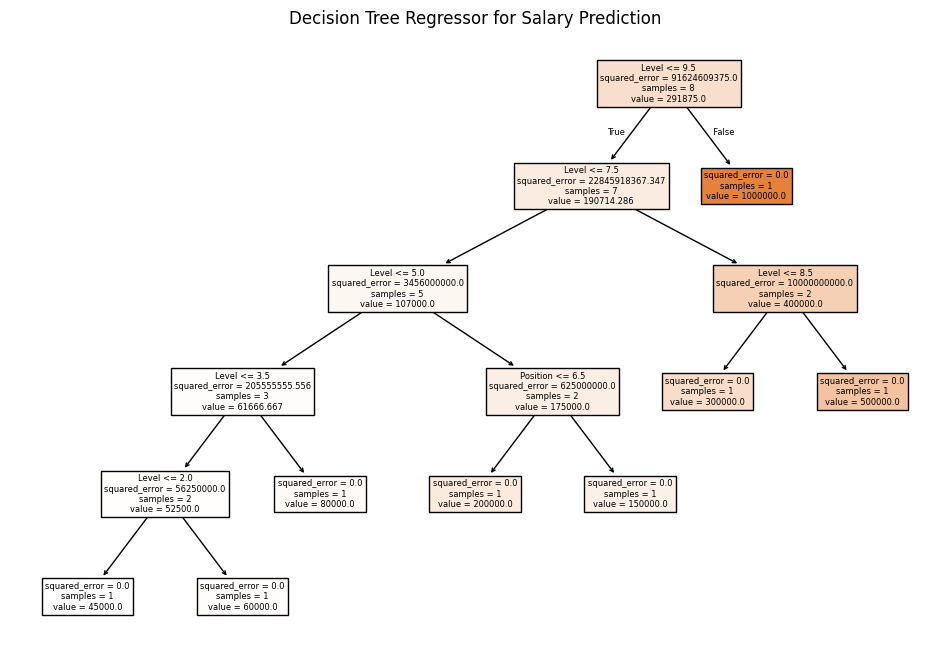


Feature Importances:


,0
Position,0.001705
Level,0.998295


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

# 1) Load dataset
csv_path = "Salary.csv"    # <-- Change path if needed
try:
    data = pd.read_csv(csv_path)
except FileNotFoundError:
    raise FileNotFoundError(f"File not found at: {csv_path}. Update the path.")

print("Dataset Loaded Successfully!\n")

# 2) Data exploration
print("Shape:", data.shape)
display(data.head())
print("\nInfo:")
display(data.info())
print("\nMissing Values:\n", data.isnull().sum())

# 3) Encode categorical column 'Position'
if "Position" in data.columns:
    le = LabelEncoder()
    data["Position"] = le.fit_transform(data["Position"])
    print("\nLabel Encoding Mapping (Position):")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(mapping)

# 4) Select features and target
X = data[["Position", "Level"]]
y = data["Salary"]

print("\nFeature Sample:")
display(X.head())
print("\nTarget Sample:")
display(y.head())

# 5) Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)
print(f"\nTrain Size: {X_train.shape}, Test Size: {X_test.shape}")

# 6) Initialize and train Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=10)
dt.fit(X_train, Y_train)
print("\nModel Training Completed!")

# 7) Predict on test data
y_pred = dt.predict(X_test)
print("\nPredicted Salaries:", y_pred)

# 8) Evaluate model using R² Score
r2 = metrics.r2_score(Y_test, y_pred)
print(f"\nR² Score: {r2:.4f}")

# 9) Visualize Decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=["Position", "Level"], filled=True)
plt.title("Decision Tree Regressor for Salary Prediction")
plt.show()

# 10) Feature Importances
importances = pd.Series(dt.feature_importances_, index=["Position", "Level"])
print("\nFeature Importances:")
display(importances)
